In [ ]:
%load_ext autoreload
%autoreload 2

import os 
import sys

import pandas as pd
import numpy as np

from Preproces_prod2 import *
    
local_path = os.getcwd()
code_root = os.path.abspath(os.path.join(local_path, '..', 'Code'))

if code_root not in sys.path:
    sys.path.insert(0, code_root)
code_root = os.path.abspath(os.path.join(local_path, '../..', 'inv'))

if code_root not in sys.path:
    sys.path.insert(0, code_root)

from matching_case_control import call_data,analyze_vrs_data, integer_programming_matching_gurobi,match_nn_max_dist_weigths,comparar_medias_test, charly_mip, charly_double_mip, mylogit

import inv

from IPython.core.display import display
display.max_output_lines = 500  # Adjust the number as needed
pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)


path_actual = Path.cwd()
path_data = path_actual.parent / 'Data'

In [3]:
# Crear una función para evaluar el criterio
def check_signs(col1, col2):
    signs = np.sign([col1, col2])  # Obtiene los signos de ambos valores
    if all(signs > 0) or all(signs < 0):
        return 1  # Ambos positivos o ambos negativos
    else:
        return 0  # Signos intercalados

In [2]:
df_vrs_match_case = pd.read_csv(path_data/'df_vrs_match_case_s39_2012.csv', index_col=0)
df_upc_match_case = pd.read_csv(path_data/'df_upc_match_case_s39_2012.csv', index_col=0)

In [5]:
# df_all = call_data('NAC_RNI_EGRESOS_ENTREGA_ISCI_28_10_2024_encrip.csv')

# df = (
#     df_all
#     .query('(fechaIng_vrs > "2024-03-31") | fechaIng_vrs.isna()')
#     #.query('chile_chico==1')
#     .copy()
# )

np.random.seed(42)
list_experiments=[]

icd10_codes_fr = [
    "N390",   # Infección del tracto urinario (sin síntomas respiratorios) INFECCION DE VÍAS URINARIAS, SITIO NO ESPECIFICADO
    "A090",     # Gastroenteritis aguda (sin síntomas respiratorios) OTRAS GASTROENTERITIS Y COLITIS NO ESPECIFICADAS DE ORIGEN INFECCIOSO
    "A099",     # Gastroenteritis aguda (sin síntomas respiratorios) GASTROENTERITIS Y COLITIS DE ORIGEN NO ESPECIFICADO
    "A09X",     # Gastroenteritis aguda (sin síntomas respiratorios) DIARREA Y GASTROENTERITIS DE PRESUNO ORIGEN INFECCIOSO
    "R100",  # Cólico infantil (sin fiebre ni síntomas respiratorios) ABDOMEN AGUDO
    "R101",  # Cólico infantil (sin fiebre ni síntomas respiratorios) DOLOR ABDOMINAL LOCALIZADO EN PARTE SUPERIOR
    "R102",  # Cólico infantil (sin fiebre ni síntomas respiratorios) DOLOR PELVICO Y PERINEAL
    "R103",  # Cólico infantil (sin fiebre ni síntomas respiratorios) DOLOR LOCALIZADO EN OTRAS PARTES INFERIORES DEL ABDOMEN
    "R104",  # Cólico infantil (sin fiebre ni síntomas respiratorios) OTROS DOLORES ABDOMINALES Y LOS NO ESPECIFICADOS
    "R11X",  # Cólico infantil (sin fiebre ni síntomas respiratorios) NAUSEA Y VOMITO
    "R634",   # Pérdida de peso (sin fiebre ni síntomas respiratorios) PERDIDA ANORMAL DE PESO
    "R633",   # Dificultades de alimentación (sin fiebre ni síntomas respiratorios) DIFICULTADES Y MALA ADMINISTRACION DE LA ALIMENTACION
    "P599",   # Ictericia neonatal (sin fiebre ni síntomas respiratorios) ICTERICIA NEONATAL, NO ESPECIFICADA
    "R681",  # Llanto anormal (sin fiebre ni síntomas respiratorios) SINTOMAS NO ESPECIFICOS PROPIOS DE LA INFANCIA
    "S099",  # Traumatismo craneal (sin fiebre ni síntomas respiratorios)
    "Z539"    # Cirugía de emergencia (sin fiebre ni síntomas respiratorios)
]

regiones = df_vrs_match_case.copy().region.unique()

In [6]:
list_experiments=[]

In [7]:
df = df_vrs_match_case.copy()
df_case= df.query("diag_vrs==True").copy()
df_control_all= df.query("diag_vrs==False").copy()
df_control_francia =  df[df.DIAG1.isin(icd10_codes_fr)].copy()


In [ ]:
S_1_exact = ['SEXO','SEMANAS','group']  # ,'NOMBRE_REGION' region just usefull on national analysis
S_1_nn =  ['edad_relativa','ingreso_relativo']
S_1_ip = {'FECHA_NAC': 28, 'FECHA_ING_any':15} 

S1 = ['S1',S_1_exact, S_1_nn, S_1_ip]

#S2 = S1 + COMUNA
S_2_exact = S_1_exact + ['COMUNA']

S2 = ['S2',S_2_exact, S_1_nn, S_1_ip]

S_aux_all = {'FECHA_NAC': 28}
S_nn_aux_all = ['edad_relativa']



S0= ['S0',['SEXO','group'], S_1_nn, S_1_ip]

with open("output_regiones_match.txt", "w") as file:
    sys.stdout = file
    
    for region in regiones:
            if region==None:
                continue
            df_case_reg = df_case.copy().query('NOMBRE_REGION==@region')
            df_control_all_reg = df_control_all.copy().query('NOMBRE_REGION==@region')
            df_control_francia_reg = df_control_francia.copy().query('NOMBRE_REGION==@region')
            print(f"{region}: N° de obs case {df_case_reg.shape[0]}, control todos {df_control_all_reg.shape[0]} y control francia {df_control_francia_reg.shape[0]}")


            ############################### S0 ################################
            
            try:
                matched_data_all, feasible_controls_all = integer_programming_matching_gurobi(df_cases=df_case_reg,
                                        df_control = df_control_all_reg,
                                        match_vars = S0[1],
                                        match_date_vars = S_aux_all,
                                        intervals={})
                
                results = analyze_vrs_data(matched_data_all)
                results['method'] = 'MIP'
                results['subset'] = 'S0'
                results['region'] = region
                results['control'] = 'all'
                results['max_cases']=df_case_reg.shape[0]
                list_experiments.append(results.copy())
            except Exception as e:
                print(f"Error en matching S0 ip para {region} con todos: {e}")
            
            try:
                matched_data_francia, feasible_controls_francia = integer_programming_matching_gurobi(df_cases = df_case_reg,
                                        df_control = df_control_francia_reg,
                                        match_vars = S0[1] ,
                                        match_date_vars = S1[3],
                                        intervals = {})

                results = analyze_vrs_data(matched_data_francia)
                results['method'] ='MIP'
                results['subset'] = 'S0'
                results['region'] = region 
                results['control'] = 'francia'
                results['max_cases']=df_case_reg.shape[0]
                list_experiments.append(results.copy())
            except Exception as e:
                print(f"Error en matching S0 ip para {region} con francia: {e}")


            #########################################S1##################################################
            

            try:
                matched_data_all, feasible_controls_all = integer_programming_matching_gurobi(df_cases=df_case_reg,
                                        df_control = df_control_all_reg,
                                        match_vars = S1[1],
                                        match_date_vars = S_aux_all,
                                        intervals={})
                
                results = analyze_vrs_data(matched_data_all)
                results['method'] = 'MIP'
                results['subset'] = 'S1'
                results['region'] = region
                results['control'] = 'all'
                results['max_cases']=df_case_reg.shape[0]
                list_experiments.append(results.copy())
            except Exception as e:
                print(f"Error en matching S1 ip para {region} con control todos: {e}")
                
                
            try:
                matched_data_francia, feasible_controls_francia = integer_programming_matching_gurobi(df_cases = df_case_reg,
                                        df_control = df_control_francia_reg,
                                        match_vars = S1[1],
                                        match_date_vars = S1[3],
                                        intervals = {})

                results = analyze_vrs_data(matched_data_francia)
                results['method'] ='MIP'
                results['subset'] = 'S1'
                results['region'] = region 
                results['control'] = 'francia'
                results['max_cases']=df_case_reg.shape[0]
                list_experiments.append(results.copy())
            except Exception as e:
                print(f"Error en matching S1 ip para {region} con francia : {e}")
                
            ############################### S2 ################################
            
            try:
                matched_data_all, feasible_controls_all = integer_programming_matching_gurobi(df_cases=df_case_reg,
                                        df_control = df_control_all_reg,
                                        match_vars = S1[1] + ['COMUNA'],
                                        match_date_vars = S_aux_all,
                                        intervals={})
                
                results = analyze_vrs_data(matched_data_all)
                results['method'] = 'MIP'
                results['subset'] = 'S2'
                results['region'] = region
                results['control'] = 'all'
                results['max_cases']=df_case_reg.shape[0]
                list_experiments.append(results.copy())
            except Exception as e:
                print(f"Error en matching S2 ip para {region} con todos: {e}")
            
            try:
                matched_data_francia, feasible_controls_francia = integer_programming_matching_gurobi(df_cases = df_case_reg,
                                        df_control = df_control_francia_reg,
                                        match_vars = S1[1] + ['COMUNA'],
                                        match_date_vars = S1[3],
                                        intervals = {})

                results = analyze_vrs_data(matched_data_francia)
                results['method'] ='MIP'
                results['subset'] = 'S2'
                results['region'] = region 
                results['control'] = 'francia'
                results['max_cases']=df_case_reg.shape[0]
                list_experiments.append(results.copy())
            except Exception as e:
                print(f"Error en matching S2 ip para {region} con francia: {e}")
                
                

            ############################ NN ###########################
            
            #################S0#########################
            
            try:
                matched_data_all, matched_incompleto, matched_controls = match_nn_max_dist_weigths(df_control_all_reg, df_case_reg,
                                                                    match_vars_nn = S_nn_aux_all,
                                                                    match_vars_exact = S0[1],
                                                                    match_vars_onehot = [],
                                                                    ratio="1:1",
                                                                    max_distance=50,
                                                                    weights={})
                
                results = analyze_vrs_data(matched_data_all)
                results['method'] ='NN'
                results['subset'] = 'S0'
                results['region'] = region
                results['control'] = 'all'
                results['max_cases']=df_case_reg.shape[0]
                list_experiments.append(results.copy())
            except Exception as e:
                print(f"Error en matching S0 nn para {region} con todos: {e}")
                
                
            try:
                matched_data_all, matched_incompleto, matched_controls = match_nn_max_dist_weigths(df_control_francia_reg, df_case_reg,
                                                                    match_vars_nn = S0[2],
                                                                    match_vars_exact = S0[1],
                                                                    match_vars_onehot = [],
                                                                    ratio="1:1",
                                                                    max_distance=50,
                                                                    weights={})
                
                results = analyze_vrs_data(matched_data_all)
                results['method'] ='NN'
                results['subset'] = 'S1'
                results['region'] = region 
                results['control'] = 'francia'
                results['max_cases']=df_case_reg.shape[0]
                list_experiments.append(results.copy())
            except Exception as e:
                print(f"Error en matching S0 nn para {region} con francia: {e}")
            
            #############################################S1##########################################
            try:
                matched_data_all, matched_incompleto, matched_controls = match_nn_max_dist_weigths(df_control_all_reg, df_case_reg,
                                                                    match_vars_nn = S_nn_aux_all,
                                                                    match_vars_exact = S1[1],
                                                                    match_vars_onehot = [],
                                                                    ratio="1:1",
                                                                    max_distance=50,
                                                                    weights={})
                
                results = analyze_vrs_data(matched_data_all)
                results['method'] ='NN'
                results['subset'] = 'S1'
                results['region'] = region
                results['control'] = 'all'
                results['max_cases']=df_case_reg.shape[0]
                list_experiments.append(results.copy())
            except Exception as e:
                print(f"Error en matching S1 nn para {region} con todos: {e}")
            
            try:
                matched_data_all, matched_incompleto, matched_controls = match_nn_max_dist_weigths(df_control_francia_reg, df_case_reg,
                                                                    match_vars_nn = S1[2],
                                                                    match_vars_exact = S1[1],
                                                                    match_vars_onehot = [],
                                                                    ratio="1:1",
                                                                    max_distance=50,
                                                                    weights={})
                
                results = analyze_vrs_data(matched_data_all)
                results['method'] ='NN'
                results['subset'] = 'S1'
                results['region'] = region 
                results['control'] = 'francia'
                results['max_cases']=df_case_reg.shape[0]
                list_experiments.append(results.copy())
            except Exception as e:
                print(f"Error en matching S1 nn para {region} con francia: {e}")
            
            ############################ NN S2 ###########################
            try: 
                matched_data_all, matched_incompleto, matched_controls = match_nn_max_dist_weigths(df_control_all_reg, df_case_reg,
                                                                    match_vars_nn = S_nn_aux_all,
                                                                    match_vars_exact = S1[1],
                                                                    match_vars_onehot = ['COMUNA'],
                                                                    ratio="1:1",
                                                                    max_distance=50,
                                                                    weights={})
                
                results = analyze_vrs_data(matched_data_all)
                results['method'] ='NN'
                results['subset'] = 'S2'
                results['region'] = region
                results['control'] = 'all'
                results['max_cases']=df_case_reg.shape[0]
                list_experiments.append(results.copy())
            except Exception as e:
                print(f"Error en matching S2 nn para {region} con todos: {e}")
            
            try: 
                matched_data_all, matched_incompleto, matched_controls = match_nn_max_dist_weigths(df_control_francia_reg, df_case_reg,
                                                                    match_vars_nn = S1[2],
                                                                    match_vars_exact = S1[1],
                                                                    match_vars_onehot = ['COMUNA'],
                                                                    ratio="1:1",
                                                                    max_distance=50,
                                                                    weights={})
                
                results = analyze_vrs_data(matched_data_all)
                results['method'] ='NN'
                results['subset'] = 'S2'
                results['region'] = region 
                results['control'] = 'francia'
                results['max_cases']=df_case_reg.shape[0]
                list_experiments.append(results.copy())
            except Exception as e:
                print(f"Error en matching S2 nn para {region} con francia: {e}")
            
            print('\n')   

In [7]:
S_1_exact = ['sexo','SEMANAS','group']  # ,'NOMBRE_REGION' region just usefull on national analysis
S_1_nn =  ['edad_relativa','ingreso_relativo']
S_1_ip = {'fecha_nac': 28, 'fechaIng_any':15} 

S1 = ['S1',S_1_exact, S_1_nn, S_1_ip]

#S2 = S1 + COMUNA
S_2_exact = S_1_exact + ['COMUNA']

S2 = ['S2',S_2_exact, S_1_nn, S_1_ip]

S_aux_all = {'fecha_nac': 28}
S_nn_aux_all = ['edad_relativa']

S0= ['S0',['sexo','group'], S_1_nn, S_1_ip]
    
for region in regiones:
    
    if region==None:
        continue
    
    df_case_reg = df_case.copy().query('region==@region')
    df_control_all_reg = df_control_all.copy().query('region==@region')
    df_control_francia_reg = df_control_francia.copy().query('region==@region')
    print(f"{region}: N° de obs case {df_case_reg.shape[0]}, control todos {df_control_all_reg.shape[0]} y control francia {df_control_francia_reg.shape[0]}")

    ############################## S0 ################################
    
    try:
        matched_data_all, feasible_controls_all = integer_programming_matching_gurobi(df_cases=df_case_reg,
                                df_control = df_control_all_reg,
                                match_vars = S0[1],
                                match_date_vars = S_aux_all,
                                intervals={})
        
        results = analyze_vrs_data(matched_data_all)
        results['method'] = 'MIP'
        results['subset'] = 'S0'
        results['region'] = region
        results['control'] = 'all'
        results['max_cases']=df_case_reg.shape[0]
        list_experiments.append(results.copy())
    except Exception as e:
        print(f"Error en matching S0 ip para {region} con todos: {e}")
    
    try:
        matched_data_francia, feasible_controls_francia = integer_programming_matching_gurobi(df_cases = df_case_reg,
                                df_control = df_control_francia_reg,
                                match_vars = S0[1] ,
                                match_date_vars = S0[3],
                                intervals = {})

        results = analyze_vrs_data(matched_data_francia)
        results['method'] ='MIP'
        results['subset'] = 'S0'
        results['region'] = region 
        results['control'] = 'francia'
        results['max_cases']=df_case_reg.shape[0]
        list_experiments.append(results.copy())
    except Exception as e:
        print(f"Error en matching S0 ip para {region} con francia: {e}")


    #########################################S1##################################################
    

    try:
        matched_data_all, feasible_controls_all = integer_programming_matching_gurobi(df_cases=df_case_reg,
                                df_control = df_control_all_reg,
                                match_vars = S1[1],
                                match_date_vars = S_aux_all,
                                intervals={})
        
        results = analyze_vrs_data(matched_data_all)
        results['method'] = 'MIP'
        results['subset'] = 'S1'
        results['region'] = region
        results['control'] = 'all'
        results['max_cases']=df_case_reg.shape[0]
        list_experiments.append(results.copy())
    except Exception as e:
        print(f"Error en matching S1 ip para {region} con control todos: {e}")
        
        
    try:
        matched_data_francia, feasible_controls_francia = integer_programming_matching_gurobi(df_cases = df_case_reg,
                                df_control = df_control_francia_reg,
                                match_vars = S1[1],
                                match_date_vars = S1[3],
                                intervals = {})

        results = analyze_vrs_data(matched_data_francia)
        results['method'] ='MIP'
        results['subset'] = 'S1'
        results['region'] = region 
        results['control'] = 'francia'
        results['max_cases']=df_case_reg.shape[0]
        list_experiments.append(results.copy())
    except Exception as e:
        print(f"Error en matching S1 ip para {region} con francia : {e}")
        
    ############################### S2 ################################
    
    try:
        matched_data_all, feasible_controls_all = integer_programming_matching_gurobi(df_cases=df_case_reg,
                                df_control = df_control_all_reg,
                                match_vars = S1[1] + ['COMUNA'],
                                match_date_vars = S_aux_all,
                                intervals={})
        
        results = analyze_vrs_data(matched_data_all)
        results['method'] = 'MIP'
        results['subset'] = 'S2'
        results['region'] = region
        results['control'] = 'all'
        results['max_cases']=df_case_reg.shape[0]
        list_experiments.append(results.copy())
    except Exception as e:
        print(f"Error en matching S2 ip para {region} con todos: {e}")
    
    try:
        matched_data_francia, feasible_controls_francia = integer_programming_matching_gurobi(df_cases = df_case_reg,
                                df_control = df_control_francia_reg,
                                match_vars = S1[1] + ['COMUNA'],
                                match_date_vars = S1[3],
                                intervals = {})

        results = analyze_vrs_data(matched_data_francia)
        results['method'] ='MIP'
        results['subset'] = 'S2'
        results['region'] = region 
        results['control'] = 'francia'
        results['max_cases']=df_case_reg.shape[0]
        list_experiments.append(results.copy())
    except Exception as e:
        print(f"Error en matching S2 ip para {region} con francia: {e}")
        
        

    ############################ NN ###########################
    
    #################S0#########################
    
    try:
        matched_data_all, matched_incompleto, matched_controls = match_nn_max_dist_weigths(df_control_all_reg, df_case_reg,
                                                            match_vars_nn = S_nn_aux_all,
                                                            match_vars_exact = S0[1],
                                                            match_vars_onehot = [],
                                                            ratio="1:1",
                                                            max_distance=50,
                                                            weights={})
        
        results = analyze_vrs_data(matched_data_all)
        results['method'] ='NN'
        results['subset'] = 'S0'
        results['region'] = region
        results['control'] = 'all'
        results['max_cases']=df_case_reg.shape[0]
        list_experiments.append(results.copy())
    except Exception as e:
        print(f"Error en matching S0 nn para {region} con todos: {e}")
        
        
    try:
        matched_data_all, matched_incompleto, matched_controls = match_nn_max_dist_weigths(df_control_francia_reg, df_case_reg,
                                                            match_vars_nn = S0[2],
                                                            match_vars_exact = S0[1],
                                                            match_vars_onehot = [],
                                                            ratio="1:1",
                                                            max_distance=50,
                                                            weights={})
        
        results = analyze_vrs_data(matched_data_all)
        results['method'] ='NN'
        results['subset'] = 'S0'
        results['region'] = region 
        results['control'] = 'francia'
        results['max_cases']=df_case_reg.shape[0]
        list_experiments.append(results.copy())
    except Exception as e:
        print(f"Error en matching S0 nn para {region} con francia: {e}")
    
    #############################################S1##########################################
    try:
        matched_data_all, matched_incompleto, matched_controls = match_nn_max_dist_weigths(df_control_all_reg, df_case_reg,
                                                            match_vars_nn = S_nn_aux_all,
                                                            match_vars_exact = S1[1],
                                                            match_vars_onehot = [],
                                                            ratio="1:1",
                                                            max_distance=50,
                                                            weights={})
        
        results = analyze_vrs_data(matched_data_all)
        results['method'] ='NN'
        results['subset'] = 'S1'
        results['region'] = region
        results['control'] = 'all'
        results['max_cases']=df_case_reg.shape[0]
        list_experiments.append(results.copy())
    except Exception as e:
        print(f"Error en matching S1 nn para {region} con todos: {e}")
    
    try:
        matched_data_all, matched_incompleto, matched_controls = match_nn_max_dist_weigths(df_control_francia_reg, df_case_reg,
                                                            match_vars_nn = S1[2],
                                                            match_vars_exact = S1[1],
                                                            match_vars_onehot = [],
                                                            ratio="1:1",
                                                            max_distance=50,
                                                            weights={})
        
        results = analyze_vrs_data(matched_data_all)
        results['method'] ='NN'
        results['subset'] = 'S1'
        results['region'] = region 
        results['control'] = 'francia'
        results['max_cases']=df_case_reg.shape[0]
        list_experiments.append(results.copy())
    except Exception as e:
        print(f"Error en matching S1 nn para {region} con francia: {e}")
    
    ############################ NN S2 ###########################
    try: 
        matched_data_all, matched_incompleto, matched_controls = match_nn_max_dist_weigths(df_control_all_reg, df_case_reg,
                                                            match_vars_nn = S_nn_aux_all,
                                                            match_vars_exact = S1[1],
                                                            match_vars_onehot = ['COMUNA'],
                                                            ratio="1:1",
                                                            max_distance=50,
                                                            weights={})
        
        results = analyze_vrs_data(matched_data_all)
        results['method'] ='NN'
        results['subset'] = 'S2'
        results['region'] = region
        results['control'] = 'all'
        results['max_cases']=df_case_reg.shape[0]
        list_experiments.append(results.copy())
    except Exception as e:
        print(f"Error en matching S2 nn para {region} con todos: {e}")
    
    try: 
        matched_data_all, matched_incompleto, matched_controls = match_nn_max_dist_weigths(df_control_francia_reg, df_case_reg,
                                                            match_vars_nn = S1[2],
                                                            match_vars_exact = S1[1],
                                                            match_vars_onehot = ['COMUNA'],
                                                            ratio="1:1",
                                                            max_distance=50,
                                                            weights={})
        
        results = analyze_vrs_data(matched_data_all)
        results['method'] ='NN'
        results['subset'] = 'S2'
        results['region'] = region 
        results['control'] = 'francia'
        results['max_cases']=df_case_reg.shape[0]
        list_experiments.append(results.copy())
    except Exception as e:
        print(f"Error en matching S2 nn para {region} con francia: {e}")
    
    print('\n')   

BIOBIO: N° de obs case 121, control todos 13718 y control francia 602
creacion conjuntos A_i time: 4.355687379837036
creacion variables time: 0.47432470321655273
optimize model time: 0.09428238868713379
matched_data time: 0.294619083404541
Total cases matched is : 121
creacion conjuntos A_i time: 0.34052109718322754
creacion variables time: 0.0009996891021728516
optimize model time: 0.0
matched_data time: 0.035469770431518555
Total cases matched is : 73
creacion conjuntos A_i time: 4.193126201629639
creacion variables time: 0.22825860977172852
optimize model time: 0.01895928382873535
matched_data time: 0.11426305770874023
Total cases matched is : 120
creacion conjuntos A_i time: 0.36862897872924805
creacion variables time: 0.0
optimize model time: 0.0
matched_data time: 0.015001058578491211
Total cases matched is : 31
creacion conjuntos A_i time: 4.105178356170654
creacion variables time: 0.00546717643737793
optimize model time: 0.0020012855529785156
matched_data time: 0.06683492660522

In [27]:
L=[0,1,2,3,4,5,6,7,8]

In [28]:
L[3:]

[3, 4, 5, 6, 7, 8]

In [30]:
list_experiments_copy = list_experiments.copy()

In [31]:
list_experiments = list_experiments[3:]

In [32]:
# Lista para almacenar los DataFrames de cada experimento con el nombre del experimento
experiment_dfs = []

for result in list_experiments:
    # Obtener el DataFrame de resultados
    results_df_transposed =(
        result['results_df'].T
        .assign(
            str_values = lambda df : f'{str(df["Efectividad"].values[0].round(2))} ({str(df["0.025 Conf Interval"].values[0].round(2))}; {str(df["0.975 Conf Interval"].values[0].round(2))})',
            n_matched_cases = result['df_matched'].Group.nunique(),
            porc_n_matched_cases = result['df_matched'].Group.nunique()/result['max_cases'],
            pseudo_p_value = lambda df : check_signs(df['0.025 Conf Interval'], df['0.975 Conf Interval'])
        )
        .assign(
                method = result['method'],
                subset = result['subset'],
                control = result['control'],
                region = result['region']
            )
        .pipe(lambda df:df.set_index(['region','method','subset','control']))
        ) 
    
    # Añadir el DataFrame a la lista
    experiment_dfs.append(results_df_transposed)

# Concatenar todos los DataFrames en uno solo
all_results_df = pd.concat(experiment_dfs, ignore_index=False)

# Mostrar el DataFrame concatenado
#display(all_results_df)




marcel_summary= (all_results_df[['str_values']]
#.reset_index()
.unstack(-1)
.unstack(-2)
.unstack(-1)
)

display(marcel_summary)



str_values  \
control                                                    all   
method                                                     MIP   
subset                                                      S0   
region                                                           
ANTOFAGASTA             100.0 (-1.7332636571237511e+53; 100.0)   
ARAUCANIA                               33.33 (-136.25; 81.19)   
ARICA Y PARINACOTA      100.0 (-3.8356929265407085e+78; 100.0)   
ATACAMA                                   0.0 (-609.91; 85.91)   
BIOBIO                                    81.82 (56.61; 92.38)   
COQUIMBO                                 55.56 (-44.32; 86.31)   
LOS LAGOS                                57.14 (-11.52; 83.53)   
LOS RIOS                99.99 (-1.7781966301352524e+77; 100.0)   
MAGALLANES Y ANTARTICA   100.0 (-4.888973372932482e+91; 100.0)   
MAULE                                      90.0 (21.88; 98.72)   
METROPOLITANA                             89.92 (81.74; 94.43)   
NUBLE                                     80.0 (-71.19; 97.66)   
O'HIGGINS                                 50.0 (-66.04; 84.94)   
TARAPACA                                 85.71 (-16.11; 98.24)   
VALPARAISO                                87.09 (63.44; 95.44)   

                                                                \
control                                                          
method                                                           
subset                                                      S1   
region                                                           
ANTOFAGASTA             99.99 (-2.0844263960467316e+57; 100.0)   
ARAUCANIA                                57.14 (-65.73; 88.92)   
ARICA Y PARINACOTA       100.0 (-3.208467505051991e+79; 100.0)   
ATACAMA                                   0.0 (-609.91; 85.91)   
BIOBIO                                    78.57 (48.25; 91.13)   
COQUIMBO                                 50.0 (-172.98; 90.84)   
LOS LAGOS                                 78.57 (25.43; 93.84)   
LOS RIOS                99.99 (-5.2482708980404396e+82; 100.0)   
MAGALLANES Y ANTARTICA                   0.0 (-1498.75; 93.75)   
MAULE                                    55.56 (-44.32; 86.31)   
METROPOLITANA                              67.89 (53.0; 78.06)   
NUBLE                                    66.66 (-65.16; 93.27)   
O'HIGGINS                                42.85 (-95.23; 83.27)   
TARAPACA                                    87.5 (0.06; 98.44)   
VALPARAISO                                 80.0 (51.95; 91.68)   

                                                                \
control                                                          
method                                                           
subset                                                      S2   
region                                                           
ANTOFAGASTA                               80.0 (-71.19; 97.66)   
ARAUCANIA                               66.66 (-220.48; 96.53)   
ARICA Y PARINACOTA       100.0 (-3.208467505051991e+79; 100.0)   
ATACAMA                                  50.0 (-451.41; 95.47)   
BIOBIO                                    74.99 (45.74; 88.48)   
COQUIMBO                                 55.56 (-44.32; 86.31)   
LOS LAGOS                                 81.82 (17.97; 95.97)   
LOS RIOS                99.99 (-5.2482708980404396e+82; 100.0)   
MAGALLANES Y ANTARTICA                   0.0 (-1498.75; 93.75)   
MAULE                                     84.61 (31.82; 96.53)   
METROPOLITANA                              89.06 (81.01; 93.7)   
NUBLE                                    66.66 (-220.5; 96.53)   
O'HIGGINS                100.0 (-6.417223252350757e+43; 100.0)   
TARAPACA                                  75.0 (-17.73; 94.69)   
VALPARAISO                                70.37 (34.78; 86.54)   

                                                                \
control                

In [77]:
all_results_df

Coeficientes            OR  \
region                 method subset control                               
BIOBIO                 MIP    S0     all         -1.704702      0.181827   
                                     francia     -3.044474      0.047621   
                              S1     all         -1.540424      0.214290   
                                     francia    -10.314604      0.000033   
                              S2     all         -1.385985      0.250077   
                                     francia    -10.557846      0.000026   
                       NN     S0     all         -2.802389      0.060665   
                                     francia     -2.078858      0.125073   
                              S1     all         -2.169046      0.114287   
                                     francia     -1.824458      0.161305   
                              S2     all         -1.704702      0.181827   
                                     francia     -2.014474      0.133391   
METROPOLITANA          MIP    S0     all         -2.294180      0.100844   
                                     francia     -2.917749      0.054055   
                              S1     all         -1.107742      0.330304   
                                     francia     -3.931488      0.019614   
                              S2     all         -2.212962      0.109376   
                                     francia     -9.122226      0.000109   
                       NN     S0     all         -3.090972      0.045458   
                                     francia     -4.158503      0.015631   
                              S1     all         -2.839623      0.058448   
                                     francia     -4.403835      0.012230   
                              S2     all         -2.212959      0.109376   
                                     francia     -2.870447      0.056674   
VALPARAISO             MIP    S0     all         -1.455284      0.233334   
                                     francia     -0.998505      0.368430   
                              S1     all         -1.609422      0.200003   
                                     francia     -2.079436      0.125001   
                              S2     all         -1.216291      0.296327   
                                     francia    -10.007338      0.000045   
                       NN     S0     all         -1.824463      0.161304   
                                     francia     -1.011597      0.363638   
                              S1     all         -1.886969      0.151530   
                                     francia     -2.047440      0.129065   
                              S2     all         -1.642210      0.193552   
                                     francia     -1.791705      0.166676   
COQUIMBO               MIP    S0     all         -0.810923      0.444448   
                                     francia     -1.945331      0.142940   
                              S1     all         -0.693142      0.500003   
                                     francia     -9.122226      0.000109   
                              S2     all         -0.810925      0.444447   
                                     francia     11.235421  75767.239499   
                       NN     S0     all         -2.302525      0.100006   
                                     francia     -1.504061      0.222226   
                              S1     all         -1.609396      0.200008   
                                     francia     -1.203831      0.300043   
                              S2     all         -9.908594      0.000050   
                                     francia     -0.916283      0.400003   
LOS LAGOS              MIP    S0     all         -0.847297      0.428572   
                                     francia     -9.748744      0.000058   
                              S1     all         -1.540439      0.214287   
                  

In [ ]:
weights = {'edad_relativa': 1.5,'ingreso_relativo':10}

matched_data, matched_incompleto, matched_controls = match_nn_max_dist_weigths(df_control, df_case,
                                                              match_vars_nn=['edad_relativa','ingreso_relativo'], 
                                                              match_vars_exact = ['SEXO','SEMANAS','group'],
                                                              match_vars_onehot=['COMUNA'],
                                                              ratio="1:1",
                                                              max_distance=10,
                                                              weights=weights)


results = analyze_vrs_data(matched_data)


In [74]:
marcel_summary.to_csv(path_data/'marcel_summary.csv')

In [75]:
df_case_cos= df.query("estado_inmunizacion==1").copy()
df_control_cos= df.query("estado_inmunizacion==0").copy()

In [ ]:
#Primer experimento: hacemos matching x ESTABLECIMEINTO
# Paso 1: Aplicar el matching con opciones de intervalos
intervals = {'PESO': 300}  # Por ejemplo, 5 kilos y 3 días de intervalo
match_vars = ['SEXO','PESO','NOMBRE_REGION','ESTAB'] #[,'COMUNA_N' 'ESTAB'
match_date_vars =  {'FECHA_NAC': 28} 
# Aplicamos la función de matching con la variable de fecha
matched_data, feasible_controls = integer_programming_matching_gurobi(df_cases=df_case_cos,
                                 df_control=df_control_cos,
                                 match_vars=match_vars,
                                 match_date_vars=match_date_vars,
                                 intervals=intervals)

Set parameter Username
Academic license - for non-commercial use only - expires 2025-08-23
creacion conjuntos A_i time: 440.14813923835754
creacion variables time: 0.044000864028930664
optimize model time: 0.1419990062713623
matched_data time: 0.9160041809082031
Total cases matched is : 1094


In [33]:
def generate_marcel_summary(all_results_df, porc_threshold=0.1, n_cases_threshold=5):
    """
    Genera marcel_summary filtrando por:
      - porc_n_matched_cases menor a un umbral (se reemplazan los valores con NaN).
      - n_matched_cases menor al umbral (se reemplazan los valores con NaN).
      - pseudo_p_value distinto de 1 (se reemplazan los valores con NaN).
    
    Parámetros:
    - all_results_df (DataFrame): DataFrame principal con resultados de experimentos.
    - porc_threshold (float): Umbral para filtrar porc_n_matched_cases.
    - n_cases_threshold (int): Umbral para filtrar n_matched_cases.

    Retorna:
    - DataFrame: Resumen con las condiciones aplicadas.
    """
    # Crear copia del DataFrame para no modificar el original
    filtered_df = all_results_df.copy()

    # Asignar NaN donde porc_n_matched_cases < porc_threshold
    filtered_df.loc[filtered_df['porc_n_matched_cases'] < porc_threshold, 'Efectividad'] = np.nan

    # Asignar NaN donde n_matched_cases < n_cases_threshold
    filtered_df.loc[filtered_df['n_matched_cases'] < n_cases_threshold, 'Efectividad'] = np.nan

    # Asignar NaN donde pseudo_p_value != 1
    filtered_df.loc[filtered_df['pseudo_p_value'] != 1, 'Efectividad'] = np.nan

    # Generar el resumen marcel_summary
    marcel_summary = (
        filtered_df[['Efectividad']]
        .unstack(-1)
        .unstack(-2)
        .unstack(-1)
    )

    return marcel_summary

In [34]:

# Generar el resumen con las condiciones dadas
porc_threshold = 0.1  # Umbral para porc_n_matched_cases
n_cases_threshold = 5  # Umbral para n_matched_cases

marcel_summary_filtered = generate_marcel_summary(
    all_results_df, 
    porc_threshold=porc_threshold, 
    n_cases_threshold=n_cases_threshold
)

In [36]:
marcel_summary_filtered.round(0)

Efectividad                                        \
control                        all                               francia   
method                         MIP                NN                 MIP   
subset                          S0    S1    S2    S0    S1    S2      S0   
region                                                                     
ANTOFAGASTA                    NaN   NaN   NaN   NaN   NaN   NaN     NaN   
ARAUCANIA                      NaN   NaN   NaN   NaN   NaN   NaN     NaN   
ARICA Y PARINACOTA             NaN   NaN   NaN   NaN   NaN   NaN     NaN   
ATACAMA                        NaN   NaN   NaN   NaN   NaN   NaN     NaN   
BIOBIO                        82.0  79.0  75.0  94.0  89.0  82.0    95.0   
COQUIMBO                       NaN   NaN   NaN  90.0  80.0   NaN     NaN   
LOS LAGOS                      NaN  79.0  82.0  87.0  93.0  77.0     NaN   
LOS RIOS                       NaN   NaN   NaN   NaN   NaN   NaN     NaN   
MAGALLANES Y ANTARTICA         NaN   NaN   NaN   NaN   NaN   NaN     NaN   
MAULE                         90.0   NaN  85.0  83.0   NaN  92.0     NaN   
METROPOLITANA                 90.0  68.0  89.0  95.0  94.0  90.0    95.0   
NUBLE                          NaN   NaN   NaN   NaN   NaN   NaN     NaN   
O'HIGGINS                      NaN   NaN   NaN   NaN  87.0   NaN     NaN   
TARAPACA                       NaN  87.0   NaN   NaN   NaN  87.0     NaN   
VALPARAISO                    87.0  80.0  70.0  84.0  85.0  85.0    63.0   

                                                    
control                                             
method                              NN              
subset                    S1  S2    S0    S1    S2  
region                                              
ANTOFAGASTA              NaN NaN   NaN   NaN   NaN  
ARAUCANIA                NaN NaN   NaN   NaN   NaN  
ARICA Y PARINACOTA       NaN NaN   NaN   NaN   NaN  
ATACAMA                  NaN NaN   NaN   NaN   NaN  
BIOBIO                   NaN NaN  87.0  84.0  87.0  
COQUIMBO                 NaN NaN   NaN   NaN   NaN  
LOS LAGOS                NaN NaN   NaN  92.0  92.0  
LOS RIOS                 NaN NaN   NaN   NaN   NaN  
MAGALLANES Y ANTARTICA   NaN NaN   NaN   NaN   NaN  
MAULE                    NaN NaN   NaN   NaN  82.0  
METROPOLITANA           98.0 NaN  98.0  99.0  94.0  
NUBLE                    NaN NaN   NaN   NaN   NaN  
O'HIGGINS                NaN NaN   NaN  90.0  90.0  
TARAPACA                 NaN NaN   NaN  87.0   NaN  
VALPARAISO              87.0 NaN  64.0  87.0  83.0

Efectividad                                   \
control                        all                                    
method                         MIP                               NN   
subset                          S0         S1         S2         S0   
region                                                                
ANTOFAGASTA                    NaN        NaN        NaN        NaN   
ARAUCANIA                      NaN        NaN        NaN        NaN   
ARICA Y PARINACOTA             NaN        NaN        NaN        NaN   
ATACAMA                        NaN        NaN        NaN        NaN   
BIOBIO                   81.817347  78.570984  74.992277  93.933505   
COQUIMBO                       NaN        NaN        NaN  89.999404   
LOS LAGOS                      NaN  78.571289  81.816869  86.663265   
LOS RIOS                       NaN        NaN        NaN        NaN   
MAGALLANES Y ANTARTICA         NaN        NaN        NaN        NaN   
MAULE                    89.999555        NaN  84.614691  83.332374   
METROPOLITANA            89.915593  67.886340  89.062380  94.656380   
NUBLE                          NaN        NaN        NaN        NaN   
O'HIGGINS                      NaN        NaN        NaN        NaN   
TARAPACA                       NaN  87.499722        NaN        NaN   
VALPARAISO               87.091170  79.999683  70.367267  83.869568   

                                                                        \
control                                         francia                  
method                                              MIP                  
subset                         S1         S2         S0         S1  S2   
region                                                                   
ANTOFAGASTA                   NaN        NaN        NaN        NaN NaN   
ARAUCANIA                     NaN        NaN        NaN        NaN NaN   
ARICA Y PARINACOTA            NaN        NaN        NaN        NaN NaN   
ATACAMA                       NaN        NaN        NaN        NaN NaN   
BIOBIO                  88.571346  81.817347  95.237865        NaN NaN   
COQUIMBO                79.999163        NaN        NaN        NaN NaN   
LOS LAGOS               92.855078  76.922965        NaN        NaN NaN   
LOS RIOS                      NaN        NaN        NaN        NaN NaN   
MAGALLANES Y ANTARTICA        NaN        NaN        NaN        NaN NaN   
MAULE                         NaN  92.306885        NaN        NaN NaN   
METROPOLITANA           94.155232  89.922213  94.594477  98.038553 NaN   
NUBLE                         NaN        NaN        NaN        NaN NaN   
O'HIGGINS               87.499880        NaN        NaN        NaN NaN   
TARAPACA                      NaN  87.499722        NaN        NaN NaN   
VALPARAISO              84.846963  84.846963  63.157016  87.499932 NaN   

                                                         
control                                                  
method                         NN                        
subset                         S0         S1         S2  
region                                                   
ANTOFAGASTA                   NaN        NaN        NaN  
ARAUCANIA                     NaN        NaN        NaN  
ARICA Y PARINACOTA            NaN        NaN        NaN  
ATACAMA                       NaN        NaN        NaN  
BIOBIO                  87.492710  83.869499  86.660942  
COQUIMBO                      NaN        NaN        NaN  
LOS LAGOS                     NaN  92.306655  92.306535  
LOS RIOS                      NaN        NaN        NaN  
MAGALLANES Y ANTARTICA        NaN        NaN        NaN  
MAULE                         NaN        NaN  81.817573  
METROPOLITANA           98.436907  98.776965  94.332639  
NUBLE                         NaN        NaN        NaN  
O'HIGGINS                     NaN  89.999812  89.999812  
TARAPACA                      NaN  87.499800        NaN  
VALPARAISO         

porc_n_matched_cases                      \
subset                                          S0                  S1   
control                                        all   francia       all   
region                 method                                            
ANTOFAGASTA            MIP                     1.0  0.368421  1.000000   
                       NN                      1.0  1.000000  1.000000   
ARAUCANIA              MIP                     1.0  0.354839  1.000000   
                       NN                      1.0  0.935484  1.000000   
ARICA Y PARINACOTA     MIP                     1.0  0.375000  0.875000   
                       NN                      1.0  0.875000  0.875000   
ATACAMA                MIP                     1.0       NaN  0.923077   
                       NN                      1.0  1.000000  1.000000   
BIOBIO                 MIP                     1.0  0.603306  0.991736   
                       NN                      1.0  0.694215  1.000000   
COQUIMBO               MIP                     1.0  0.750000  1.000000   
                       NN                      1.0  0.909091  1.000000   
LOS LAGOS              MIP                     1.0  0.333333  1.000000   
                       NN                      1.0  0.645833  1.000000   
LOS RIOS               MIP                     1.0       NaN  1.000000   
                       NN                      1.0  1.000000  1.000000   
MAGALLANES Y ANTARTICA MIP                     1.0       NaN  1.000000   
                       NN                      1.0  1.000000  1.000000   
MAULE                  MIP                     1.0  0.350000  1.000000   
                       NN                      1.0  0.750000  1.000000   
METROPOLITANA          MIP                     1.0  0.880694  1.000000   
                       NN                      1.0  0.394794  1.000000   
NUBLE                  MIP                     1.0  0.259259  0.962963   
                       NN                      1.0  0.925926  1.000000   
O'HIGGINS              MIP                     1.0  0.444444  0.972222   
                       NN                      1.0  0.916667  1.000000   
TARAPACA               MIP                     1.0  0.250000  1.000000   
                       NN                      1.0  1.000000  1.000000   
VALPARAISO             MIP                     1.0  0.716981  1.000000   
                       NN                      1.0  0.669811  1.000000   

                                                             
subset                                         S2            
control                         francia       all   francia  
region                 method                                
ANTOFAGASTA            MIP     0.105263  1.000000  0.052632  
                       NN      0.947368  1.000000  0.947368  
ARAUCANIA              MIP     0.193548  0.806452       NaN  
                       NN      0.903226  1.000000  0.903226  
ARICA Y PARINACOTA     MIP          NaN  0.875000       NaN  
                       NN      0.375000  0.875000  0.375000  
ATACAMA                MIP          NaN  0.692308       NaN  
                       NN      0.846154  1.000000  0.846154  
BIOBIO                 MIP     0.256198  0.900826  0.049587  
                       NN      0.884298  1.000000  0.892562  
COQUIMBO               MIP     0.181818  0.931818  0.045455  
                       NN      0.886364  1.000000  0.886364  
LOS LAGOS              MIP     0.125000  0.937500       NaN  
                       NN      0.875000  1.000000  0.895833  
LOS RIOS               MIP          NaN  1.000000       NaN  
                       NN      0.777778  1.000000  0.777778  
MAGALLANES Y ANTARTICA MIP          NaN  0.833333       NaN  
                       NN      0.666667  1.000000  0.666667  
MAULE                  MIP     0.125000  0.950000       NaN  
                       NN      0.950000  1.000000  0.950000  
METROPOLITANA          MI

n_matched_cases                                \
subset                                     S0             S1             S2   
control                                   all francia    all francia    all   
region                 method                                                 
ANTOFAGASTA            MIP               19.0     7.0   19.0     2.0   19.0   
                       NN                19.0    19.0   19.0    18.0   19.0   
ARAUCANIA              MIP               31.0    11.0   31.0     6.0   25.0   
                       NN                31.0    29.0   31.0    28.0   31.0   
ARICA Y PARINACOTA     MIP                8.0     3.0    7.0     NaN    7.0   
                       NN                 8.0     7.0    7.0     3.0    7.0   
ATACAMA                MIP               13.0     NaN   12.0     NaN    9.0   
                       NN                13.0    13.0   13.0    11.0   13.0   
BIOBIO                 MIP              121.0    73.0  120.0    31.0  109.0   
                       NN               121.0    84.0  121.0   107.0  121.0   
COQUIMBO               MIP               44.0    33.0   44.0     8.0   41.0   
                       NN                44.0    40.0   44.0    39.0   44.0   
LOS LAGOS              MIP               48.0    16.0   48.0     6.0   45.0   
                       NN                48.0    31.0   48.0    42.0   48.0   
LOS RIOS               MIP                9.0     NaN    9.0     NaN    9.0   
                       NN                 9.0     9.0    9.0     7.0    9.0   
MAGALLANES Y ANTARTICA MIP                6.0     NaN    6.0     NaN    5.0   
                       NN                 6.0     6.0    6.0     4.0    6.0   
MAULE                  MIP               40.0    14.0   40.0     5.0   38.0   
                       NN                40.0    30.0   40.0    38.0   40.0   
METROPOLITANA          MIP              461.0   406.0  461.0   207.0  443.0   
                       NN               461.0   182.0  461.0   285.0  461.0   
NUBLE                  MIP               27.0     7.0   26.0     NaN   21.0   
                       NN                27.0    25.0   27.0    25.0   27.0   
O'HIGGINS              MIP               36.0    16.0   35.0     4.0   29.0   
                       NN                36.0    33.0   36.0    33.0   36.0   
TARAPACA               MIP               16.0     4.0   16.0     2.0   15.0   
                       NN                16.0    16.0   16.0    13.0   16.0   
VALPARAISO             MIP              106.0    76.0  106.0    31.0   97.0   
                       NN               106.0    71.0  106.0    95.0  106.0   

                                       
subset                                 
control                       francia  
region                 method          
ANTOFAGASTA            MIP        1.0  
                       NN        18.0  
ARAUCANIA              MIP        NaN  
                       NN        28.0  
ARICA Y PARINACOTA     MIP        NaN  
                       NN         3.0  
ATACAMA                MIP        NaN  
                       NN        11.0  
BIOBIO                 MIP        6.0  
                       NN       108.0  
COQUIMBO               MIP        2.0  
                       NN        39.0  
LOS LAGOS              MIP        NaN  
                       NN        43.0  
LOS RIOS               MIP        NaN  
                       NN         7.0  
MAGALLANES Y ANTARTICA MIP        NaN  
                       NN         4.0  
MAULE                  MIP        NaN  
                       NN        38.0  
METROPOLITANA          MIP       24.0  
                       NN       371.0  
NUBLE                  MIP        NaN  
                       NN        25.0  
O'HIGGINS              MIP        NaN  
                       NN        33.0  
TARAPACA               MIP        1.0  
                       NN        13.0  
VALPARAISO             MIP        7.0  
                       

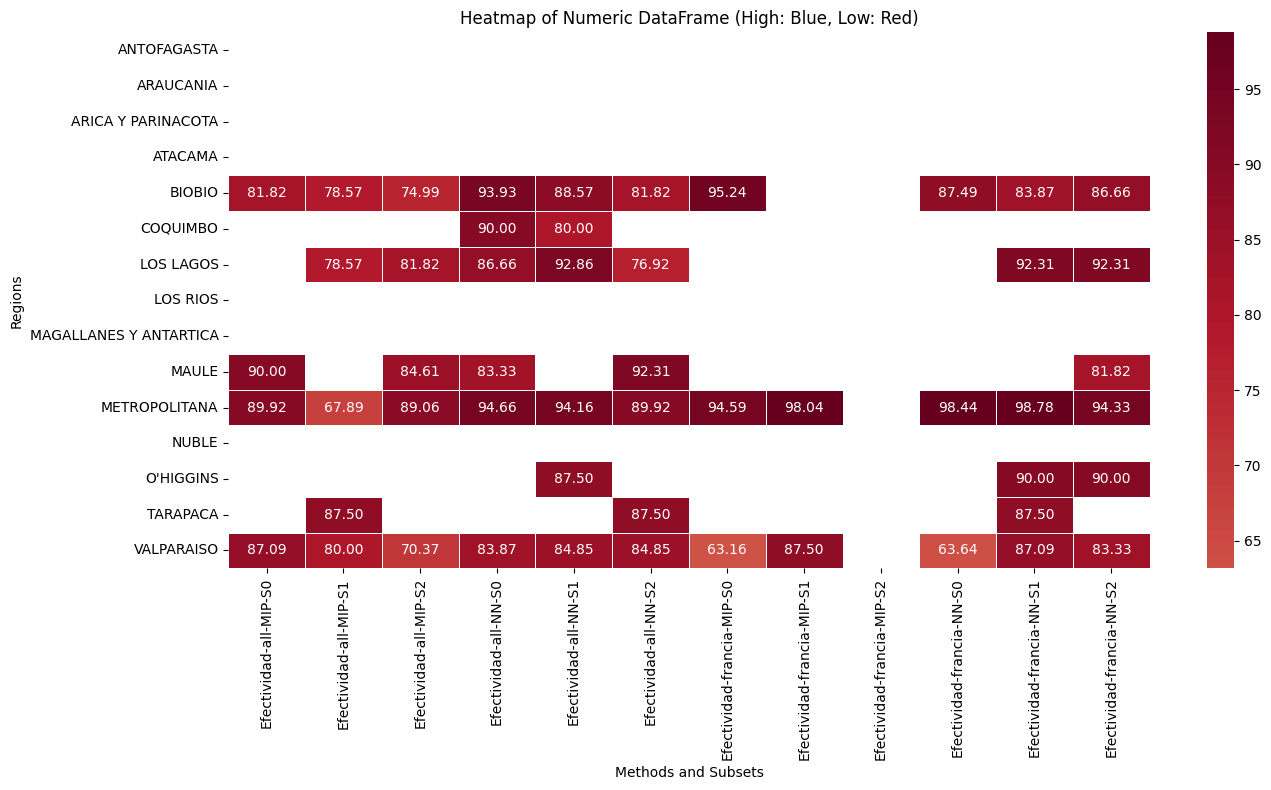

NameError: name 'binary_df' is not defined

<Figure size 1400x800 with 0 Axes>

In [37]:
# Mostrar el resultado

porc_n_matched_cases= (all_results_df[['porc_n_matched_cases']]
#.reset_index()
.unstack(-2)
.unstack(-1)

)

n_matched_cases= (all_results_df[['n_matched_cases']]
#.reset_index()
.unstack(-2)
.unstack(-1)

)
display(marcel_summary_filtered)
display(porc_n_matched_cases)
display(n_matched_cases)

#graficar
import seaborn as sns
import matplotlib.pyplot as plt

# Graficar el heatmap del DataFrame numérico
plt.figure(figsize=(14, 8))
sns.heatmap(
    marcel_summary_filtered, 
    annot=True, 
    fmt=".2f", 
    cmap="RdBu_r",  # Azul para valores altos, rojo para valores bajos
    cbar=True, 
    linewidths=0.5,
    center=0  # Centrar la escala en 0
)
plt.title("Heatmap of Numeric DataFrame (High: Blue, Low: Red)")
plt.xlabel("Methods and Subsets")
plt.ylabel("Regions")
plt.tight_layout()
plt.show()

# Graficar el heatmap del DataFrame binario
plt.figure(figsize=(14, 8))
sns.heatmap(
    binary_df, 
    annot=True, 
    fmt="d", 
    cmap="Blues",  # Azul para activaciones (1), blanco para inactivaciones (0)
    cbar=False, 
    linewidths=0.5
)
plt.title("Binary Activation Heatmap")
plt.xlabel("Methods and Subsets")
plt.ylabel("Regions")
plt.tight_layout()
plt.show()

# COX CASE

In [22]:
print(f"N° de obs case {df_case.shape[0]} y control francia {df_control_francia.shape[0]}")

N° de obs case 989 y control francia 4403


In [63]:
weights = {'edad_relativa': 7,'ingreso_relativo':10}

matched_data, matched_incompleto, matched_controls = match_nn_max_dist_weigths(df_control_francia, df_case,
                                                              match_vars_nn=['edad_relativa','ingreso_relativo'], 
                                                              match_vars_exact = ['SEXO','SEMANAS','group'],
                                                              match_vars_onehot=['COMUNA'],
                                                              ratio="1:3",
                                                              max_distance=5,
                                                              weights=weights)

display(comparar_medias_test(matched_data[~matched_data.Matched_Case_RUN.isna()],matched_data[matched_data.Matched_Case_RUN.isna()],['PESO','SEMANAS','SEXO','edad_relativa','ingreso_relativo']))


df_matched = matched_data.copy()
print('\n')
print("Dado tu estado de inmunizacion cual es probabilidad de estar contagiado")
print(df_matched.groupby('estado_inmunizacion')['diag_vrs'].mean())

print('\n')
results = analyze_vrs_data(df_matched)

print("Tabla de Contingencia:\n", results['contingency_table'])
print("\nTabla de Porcentajes:\n", results['percentage_table'])
print(f"\nOdds Ratio: {results['odds_ratio']: .2}")
print(f"Efectividad: {results['efectividad']: .3} %")
print("\nResumen del modelo:\n", results['model_summary'])
print("\nOdds Ratios y Efectividad:\n", results['odds_ratios'])

Total cases = 989, Total controls = 4403
Total cases matched is : 294, Total control matched is : 882
ratio: 1:3
No matched : 695


,Columna,Media_df1,Media_df2,T-stat,P-value,Mensaje
0,PESO,3300.09,3277.62,0.68,0.50,
1,SEMANAS,38.03,38.03,0.00,1.00,
2,SEXO,0.58,0.58,0.00,1.00,
3,edad_relativa,202.96,185.72,3.31,0.00,Existe una diferencia significativa.
4,ingreso_relativo,78.63,84.06,-1.61,0.11,




Dado tu estado de inmunizacion cual es probabilidad de estar contagiado
estado_inmunizacion
0    0.733333
1    0.195076
Name: diag_vrs, dtype: float64


Tabla de Contingencia:
 Estado de Inmunización    0     1   All
Diagnóstico VRS                        
0                        32   850   882
1                        88   206   294
All                     120  1056  1176

Tabla de Porcentajes:
 Estado de Inmunización           0           1    All
Diagnóstico VRS                                      
0                        26.666667   80.492424   75.0
1                        73.333333   19.507576   25.0
All                     100.000000  100.000000  100.0

Odds Ratio:  0.088
Efectividad:  91.2 %

Resumen del modelo:
                   Conditional Logit Model Regression Results                  
Dep. Variable:               diag_vrs   No. Observations:                 1176
Model:               ConditionalLogit   No. groups:                        294
Log-Likelihood:            

In [50]:
df_matched

,RUN,FECHA_NACIMIENTO,MES_NAC,ANO_NAC,SEXO,SEMANAS,PESO,TALLA,EDAD_M,INS_C_M,INS_N_M,COMUNA,COMUNA_N,REG_RES,URBA_RURAL,NAC_MA,FECHA_INMUNIZACION,VACUNADO,FECHA_DEFUNCION,CAUSA_DEFUNCION,VIVO,FALLECIDO_PREVIO,ESTAB,ServicioSalud,Seremi,EDAD_CANT,TIPO_EDAD,ETNIA,T_ETNIA,P_ORIGEN,PREVI,FECHA_INGRESO,AREA_FUNC_I,SER_CLIN_I,DIA_1_TRAS,MES_1_TRAS,ANO_1_TRAS,AREAF_1_TRAS,SERC_1_TRAS,DIA_2_TRAS,MES_2_TRAS,ANO_2_TRAS,AREAF_2_TRAS,SERC_2_TRAS,DIA_3_TRAS,MES_3_TRAS,ANO_3_TRAS,AREAF_3_TRAS,SERC_3_TRAS,DIA_4_TRAS,MES_4_TRAS,ANO_4_TRAS,AREAF_4_TRAS,SERC_4_TRAS,DIA_5_TRAS,MES_5_TRAS,ANO_5_TRAS,AREAF_5_TRAS,SERC_5_TRAS,DIA_6_TRAS,MES_6_TRAS,ANO_6_TRAS,AREAF_6_TRAS,SERC_6_TRAS,DIA_7_TRAS,MES_7_TRAS,ANO_7_TRAS,AREAF_7_TRAS,SERC_7_TRAS,DIA_8_TRAS,MES_8_TRAS,ANO_8_TRAS,AREAF_8_TRAS,SERC_8_TRAS,DIA_9_TRAS,MES_9_TRAS,ANO_9_TRAS,AREAF_9_TRAS,SERC_9_TRAS,FECHA_EGRESO,AREAF_EGR,SERC_EGR,DIAS_ESTAD,COND_EGR,DIAG1,DIAG2,DIAG3,DIAG4,DIAG5,DIAG6,DIAG7,DIAG8,DIAG9,DIAG10,DIAG11,FECHA_NAC,FECHA_ING,FECHA_ING_any,FECHA_EGR,VRS,group,NOMBRE_REGION,Macrozona2,fecha_tras_1,fecha_tras_2,fecha_tras_3,fecha_tras_4,fecha_tras_5,fecha_tras_6,fecha_tras_7,fecha_tras_8,fecha_tras_9,cama,fecha_upc,days_upc,dias_en_ing,dias_en_area_1,dias_en_area_2,dias_en_area_3,dias_en_area_4,dias_en_area_5,dias_en_area_6,dias_en_area_7,dias_en_area_8,dias_en_area_9,prematuro_extremo,muy_prematuro,prematuro_moderado,prematuro,days_upc_vrs,days_estad_vrs,Porcentaje Urbano,porcent_rural,is_rural,atypic_mom_age,categori_macro,categori_regions,exp_rural,event,p_00001_lognormal,p_99999_lognormal,inm_7d,inm_14d,inm_21d,inm_28d,inm_35d,inm_42d,inm_49d,inm_56d,inm_63d,inm_70d,inm_77d,inm_84d,inm_91d,inm_98d,inm_105d,inm_112d,inm_119d,age_1m,age_2m,age_3m,age_4m,age_5m,age_6m,sex*prem,inmunizado,chile_chico,estado_inmunizacion,diag_vrs,diag_1_leter,edad_relativa,ingreso_relativo,Matched_Case_RUN,Group
0,224009f08be46858b2533c2ad703cf3312cd1e14ad26d6fce18198f843e88423,24FEB2024,2,2024,0,40.0,4070.0,53.0,28,4,2,8108,8108,8.0,0,NaN,NaT,SI,NaN,NaN,SI,VIVO,118100.0,18.0,NaN,1.0,2.0,96.0,NaN,152.0,1.0,01APR2024,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,02APR2024,0,NaN,1.0,1.0,J210,NaN,J960,L22X,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-02-24,2024-04-01,2024-04-01,2024-04-02,1,CATCH_UP,BIOBIO,Centro,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,,NaT,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.0,0.998463,0.001537,0,0,1,6,1.001538,True,2112.867412,6001.942936,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2024-03-24,2024-04-24,2024-05-24,2024-06-24,2024-07-24,2024-08-24,0,0,0,0,1,J,119,0.0,NaN,224009f08be46858b2533c2ad703cf3312cd1e14ad26d6fce18198f843e88423
1,c9cc7a7421b5ca1dcc2a196ecf72d9287be02e5130dbf7fef1e24ff8d58ef765,17FEB2024,2,2024,1,38.0,3090.0,50.0,19,4,2,7201,7201,7.0,0,C,NaT,SI,NaN,NaN,SI,VIVO,116111.0,16.0,NaN,1.0,2.0,96.0,NaN,152.0,1.0,01APR2024,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,11APR2024,0,NaN,10.0,1.0,J219,NaN,U071,R160,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-02-17,2024-04-01,2024-04-01,2024-04-11,1,CATCH_UP,MAULE,Centro,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,,NaT,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,10.0,0.825541,0.174459,0,1,1,11,1.190602,True,1873.189390,5271.639121,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2024-03-17,2024-04-17,2024-05-17,2024-06-17,2024-07-17,2024-08-17,0,0,1,0,1,J,112,0.0,NaN,c9cc7a7421b5ca1dcc2a196ecf72d9287be02e5130dbf7fef1e24ff8d58ef765
2,3f87a6a80e3e29a2a98e8e4e0118b9971afcd6092f48b2378ba20df75fa2400c,12MAR2024,3,2024,1,38.0,3550.0,49.0,26,3,1,13401,13401,13.0,0,C,NaT,SI,NaN,NaN,SI,VIVO,113180.0,13.0,NaN,21.0,3.0,96.0,NaN,152.0,1.0,01APR2024,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,

In [39]:
df_matched.RUN.unique()

array(['224009f08be46858b2533c2ad703cf3312cd1e14ad26d6fce18198f843e88423',
       'c9cc7a7421b5ca1dcc2a196ecf72d9287be02e5130dbf7fef1e24ff8d58ef765',
       '3f87a6a80e3e29a2a98e8e4e0118b9971afcd6092f48b2378ba20df75fa2400c',
       ...,
       'c6929dadfe1bf1184b91121020039d157682ca2915a8075289a85ee347442210',
       '7d2fbfdf93e508696bcde9ee16386a16153e390ffc79f530e8653d6324589dcb',
       'a109f631efd5ccce91266c24e35c4284387510569650d94cd40db57445e5654c'],
      dtype=object)

In [29]:
path_actual = Path.cwd()
path_data = path_actual.parent / 'Data'
df_cox_normal = pd.read_csv(path_data/'df_281024_s31_all_meses_all_group.csv')

In [51]:
df_cos_case = df_cox_normal[df_cox_normal.RUN.isin(df_matched.RUN.unique())].copy()

In [ ]:
ctv_0 = CoxTimeVaryingFitter()
ctv_0.fit(df_cos_case[['start', 'inmunizado', 'stop', 'RUN', 'event', 'SEXO']],
          id_col="RUN", event_col="event", start_col="start", stop_col="stop")
print("N_bebes_total:", df_cos_case.drop_duplicates(subset='RUN', keep='last').shape[0])
print("N_bebes_inmune:", df_cos_case.drop_duplicates(subset='RUN', keep='last').inmunizado.sum(),
              ", i.e cobertura = ",
              round(df_cos_case.drop_duplicates(subset='RUN', keep='last').inmunizado.sum() * 100 
                    /df_cos_case.drop_duplicates(subset='RUN', keep='last').shape[0],2),"%")
print("N_bebes_VRS:", df_cos_case.drop_duplicates(subset='RUN', keep='last').event.sum())
display(printSummary(ctv_0))

N_bebes_total: 1090
N_bebes_inmune: 947.0 , i.e cobertura =  86.88 %
N_bebes_VRS: 295


,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inmunizado,-0.664,0.485,0.151,-0.959,-0.368,0.308,0.617,0.000
SEXO,0.178,-0.194,0.122,-0.061,0.416,-0.515,0.059,0.144


In [61]:
display(pd.crosstab(df_cos_case['inmunizado'],df_cos_case.event))
(pd.crosstab(df_cos_case['inmunizado'],df_cos_case.event)
 .pipe( lambda x : x/x.values.sum())
 .mul(100)
 .round(1)
)

event,False,True
inmunizado,,
0.0,1113,91
1.0,9036,204


event,False,True
inmunizado,,
0.0,10.7,0.9
1.0,86.5,2.0


In [66]:
df_case.shape[0]

989

In [76]:
intervals = {'PESO': 300}  # Por ejemplo, 5 kilos y 3 días de intervalo
match_vars = ['SEXO','PESO','NOMBRE_REGION','group'] #[,'COMUNA_N' 'ESTAB'
match_date_vars =  {'FECHA_NAC': 28} 
# Aplicamos la función de matching con la variable de fecha
matched_data, feasible_controls = integer_programming_matching_gurobi(df_cases=df_case_cos,
                                 df_control=df_control_cos,
                                 match_vars=match_vars,
                                 match_date_vars=match_date_vars,
                                 intervals={},
                                 n_control=1)

display(comparar_medias_test(matched_data[~matched_data.Matched_Case_RUN.isna()],matched_data[matched_data.Matched_Case_RUN.isna()],['PESO','SEXO','SEMANAS','edad_relativa','ingreso_relativo']))


df_matched = (matched_data)
print('\n')
print("Dado tu estado de inmunizacion cual es probabilidad de estar contagiado")
print(df_matched.groupby('estado_inmunizacion')['diag_vrs'].mean())

print('\n')
results = analyze_vrs_data(df_matched)

print("Tabla de Contingencia:\n", results['contingency_table'])
print("\nTabla de Porcentajes:\n", results['percentage_table'])
print(f"\nOdds Ratio: {results['odds_ratio']: .2}")
print(f"Efectividad: {results['efectividad']: .3} %")
print("\nResumen del modelo:\n", results['model_summary'])
print("\nOdds Ratios y Efectividad:\n", results['odds_ratios'])

KeyboardInterrupt: 

In [ ]:
df_cos_case = df_cox_normal[df_cox_normal.RUN.isin(df_matched.RUN.unique())].copy()
ctv_0 = CoxTimeVaryingFitter()
ctv_0.fit(df_cos_case[['start', 'inmunizado', 'stop', 'RUN', 'event', 'SEXO']],
          id_col="RUN", event_col="event", start_col="start", stop_col="stop")
print("N_bebes_total:", df_cos_case.drop_duplicates(subset='RUN', keep='last').shape[0])
print("N_bebes_inmune:", df_cos_case.drop_duplicates(subset='RUN', keep='last').inmunizado.sum(),
              ", i.e cobertura = ",
              round(df_cos_case.drop_duplicates(subset='RUN', keep='last').inmunizado.sum() * 100 
                    /df_cos_case.drop_duplicates(subset='RUN', keep='last').shape[0],2),"%")
print("N_bebes_VRS:", df_cos_case.drop_duplicates(subset='RUN', keep='last').event.sum())
display(printSummary(ctv_0))

N_bebes_total: 1230
N_bebes_inmune: 1000.0 , i.e cobertura =  81.3 %
N_bebes_VRS: 484


,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inmunizado,-0.661,0.484,0.106,-0.869,-0.453,0.364,0.581,0.000
SEXO,0.019,-0.019,0.096,-0.170,0.207,-0.230,0.156,0.847


In [78]:
weights = {'edad_relativa': 3}

matched_data, matched_incompleto, matched_controls = match_nn_max_dist_weigths(df_control_cos, df_case_cos,
                                                              match_vars_nn=['edad_relativa'], 
                                                              match_vars_exact = ['SEXO','SEMANAS','NOMBRE_REGION'],
                                                              match_vars_onehot=['COMUNA'],
                                                              ratio="1:1",
                                                              max_distance=5,
                                                              weights=weights)

display(comparar_medias_test(matched_data[~matched_data.Matched_Case_RUN.isna()],matched_data[matched_data.Matched_Case_RUN.isna()],['PESO','SEMANAS','SEXO','edad_relativa','ingreso_relativo']))


df_matched = matched_data.copy()
print('\n')
print("Dado tu estado de inmunizacion cual es probabilidad de estar contagiado")
print(df_matched.groupby('estado_inmunizacion')['diag_vrs'].mean())

print('\n')
results = analyze_vrs_data(df_matched)

print("Tabla de Contingencia:\n", results['contingency_table'])
print("\nTabla de Porcentajes:\n", results['percentage_table'])
print(f"\nOdds Ratio: {results['odds_ratio']: .2}")
print(f"Efectividad: {results['efectividad']: .3} %")
print("\nResumen del modelo:\n", results['model_summary'])
print("\nOdds Ratios y Efectividad:\n", results['odds_ratios'])

Total cases = 153434, Total controls = 11429
Total cases matched is : 11408, Total control matched is : 11408
ratio: 1:1
No matched : 142026


,Columna,Media_df1,Media_df2,T-stat,P-value,Mensaje
0,PESO,3310.52,3305.09,0.78,0.43,
1,SEMANAS,38.42,38.42,0.00,1.00,
2,SEXO,0.51,0.51,0.00,1.00,
3,edad_relativa,112.94,94.66,12.39,0.00,Existe una diferencia significativa.
4,ingreso_relativo,-21.59,-18.07,-1.31,0.19,




Dado tu estado de inmunizacion cual es probabilidad de estar contagiado
estado_inmunizacion
0    0.026210
1    0.058555
Name: diag_vrs, dtype: float64


Tabla de Contingencia:
 Estado de Inmunización      0      1    All
Diagnóstico VRS                            
0                       11109  10740  21849
1                         299    668    967
All                     11408  11408  22816

Tabla de Porcentajes:
 Estado de Inmunización           0          1         All
Diagnóstico VRS                                          
0                        97.379032   94.14446   95.761746
1                         2.620968    5.85554    4.238254
All                     100.000000  100.00000  100.000000

Odds Ratio:  2.3
Efectividad: -1.31e+02 %

Resumen del modelo:
                   Conditional Logit Model Regression Results                  
Dep. Variable:               diag_vrs   No. Observations:                 1826
Model:               ConditionalLogit   No. groups:             

In [79]:
df_cos_case = df_cox_normal[df_cox_normal.RUN.isin(df_matched.RUN.unique())].copy()
ctv_0 = CoxTimeVaryingFitter()
ctv_0.fit(df_cos_case[['start', 'inmunizado', 'stop', 'RUN', 'event', 'SEXO']],
          id_col="RUN", event_col="event", start_col="start", stop_col="stop")
print("N_bebes_total:", df_cos_case.drop_duplicates(subset='RUN', keep='last').shape[0])
print("N_bebes_inmune:", df_cos_case.drop_duplicates(subset='RUN', keep='last').inmunizado.sum(),
              ", i.e cobertura = ",
              round(df_cos_case.drop_duplicates(subset='RUN', keep='last').inmunizado.sum() * 100 
                    /df_cos_case.drop_duplicates(subset='RUN', keep='last').shape[0],2),"%")
print("N_bebes_VRS:", df_cos_case.drop_duplicates(subset='RUN', keep='last').event.sum())
display(printSummary(ctv_0))

N_bebes_total: 20215
N_bebes_inmune: 10325.0 , i.e cobertura =  51.08 %
N_bebes_VRS: 630


,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inmunizado,0.839,-1.315,0.086,0.670,1.008,-1.741,-0.955,0.0
SEXO,0.592,-0.807,0.084,0.428,0.755,-1.128,-0.534,0.0
